# Daily CTR Curve Prediction — LightGBM + Parametric Baseline

**Goal:** Predict the daily CTR trajectory for each creative as closely as possible to its real behaviour. A tight CTR curve prediction is the foundation for:
- Detecting fatigue early (predicted CTR deviates below the model curve → anomaly).
- Generating a data-driven fatigue day estimate to cross-validate the Smadex `fatigue_day` labels.
- Powering the dashboard's *Creative Lifecycle* view.

**Prediction task:**
> *Given a creative's design attributes and its historical CTR trajectory up to day t−1, predict CTR(t).*

**Validation strategy:** Per-creative temporal split — first 70% of days for training, last 30% for testing — so we measure how well the model extrapolates the late lifecycle of each creative.

**Models compared:**
1. **Parametric baseline** — log-quadratic curve fitted per-creative on training days.
2. **LightGBM** — global gradient-boosted model trained on all creatives' training portions, using static creative features + temporal features + lagged CTR features.

```
pip install lightgbm shap scipy scikit-learn  # if not already installed
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import shap

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
np.random.seed(42)

DATA = '../data'
TRAIN_FRAC = 0.70   # per-creative temporal split

print('Libraries loaded.')
print(f'LightGBM {lgb.__version__} | SHAP {shap.__version__}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

Libraries loaded.
LightGBM 4.6.0 | SHAP 0.51.0


## 1. Load & aggregate to creative × day level

The raw daily table has one row per `creative × country × OS × date`. We aggregate to `creative × day` (summing impressions, clicks, spend across all country/OS segments) so each creative has exactly one CTR value per day.

We also recompute `impressions_last_7d` from scratch post-aggregation (the raw column is at country/OS granularity and doesn't sum correctly).

In [2]:
raw   = pd.read_csv(f'{DATA}/creative_daily_country_os_stats.csv')
crs   = pd.read_csv(f'{DATA}/creative_summary.csv')
camp  = pd.read_csv(f'{DATA}/campaigns.csv')

# Aggregate across country × OS → one row per creative × day
daily = (
    raw
    .groupby(['creative_id', 'days_since_launch'], as_index=False)
    .agg(
        campaign_id       = ('campaign_id',        'first'),
        impressions       = ('impressions',         'sum'),
        clicks            = ('clicks',              'sum'),
        conversions       = ('conversions',         'sum'),
        spend_usd         = ('spend_usd',           'sum'),
        video_completions = ('video_completions',   'sum'),
    )
    .sort_values(['creative_id', 'days_since_launch'])
    .reset_index(drop=True)
)

# Target: daily CTR
daily['ctr'] = daily['clicks'] / daily['impressions'].clip(lower=1)

# Recompute 7-day rolling impressions (shift(1) = no leakage from current day)
daily['impressions_last_7d'] = (
    daily.groupby('creative_id')['impressions']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).sum())
    .fillna(0)
)

# Smoothed CTR for visualisation (3-day centred rolling mean)
daily['ctr_smooth'] = (
    daily.groupby('creative_id')['ctr']
    .transform(lambda x: x.rolling(3, center=True, min_periods=1).mean())
)

print(f'Aggregated rows  : {len(daily):,}')
print(f'Unique creatives : {daily["creative_id"].nunique():,}')
print(f'Days range       : {daily["days_since_launch"].min()} – {daily["days_since_launch"].max()}')
print(f'\nCTR summary (% units):')
print((daily['ctr'] * 100).describe().round(4).to_string())

Aggregated rows  : 52,349
Unique creatives : 1,080
Days range       : 0 – 73

CTR summary (% units):
count    52349.0000
mean         0.4746
std          0.3506
min          0.1143
25%          0.1901
50%          0.3391
75%          0.6604
max          2.2397


## 2. Merge creative metadata

We attach static creative features (design scores, binary flags, categorical labels) and campaign features (vertical, format, target OS, KPI goal). These are the features the model uses to differentiate CTR curves *across* creatives.

In [3]:
META_COLS = [
    'creative_id', 'creative_status', 'fatigue_day', 'total_days_active',
    'vertical', 'format', 'dominant_color', 'emotional_tone', 'hook_type', 'language',
    'text_density', 'readability_score', 'brand_visibility_score',
    'clutter_score', 'novelty_score', 'motion_score',
    'faces_count', 'product_count', 'duration_sec', 'copy_length_chars',
    'has_price', 'has_discount_badge', 'has_gameplay', 'has_ugc_style',
]
CAMP_COLS = ['campaign_id', 'target_os', 'kpi_goal', 'objective']

daily = (
    daily
    .merge(crs[META_COLS],  on='creative_id',  how='left')
    .merge(camp[CAMP_COLS], on='campaign_id',   how='left')
)

print('Metadata merged. Shape:', daily.shape)
print()
print('Creative status distribution (unique creatives):')
print(daily.drop_duplicates('creative_id')['creative_status'].value_counts().to_string())

Metadata merged. Shape: (52349, 37)

Creative status distribution (unique creatives):
creative_status
stable            740
fatigued          199
underperformer     95
top_performer      46


## 3. EDA — CTR lifecycle patterns

Before modelling, we visualise the average CTR trajectory by creative status, by format, and the weekly distribution. This reveals:
- **Fatigued** creatives: characteristic rise → sharp drop around days 10–17.
- **Top performers**: sustained high CTR throughout.
- **Stable**: modest, steady CTR.
- **Underperformers**: consistently low CTR from day 1.

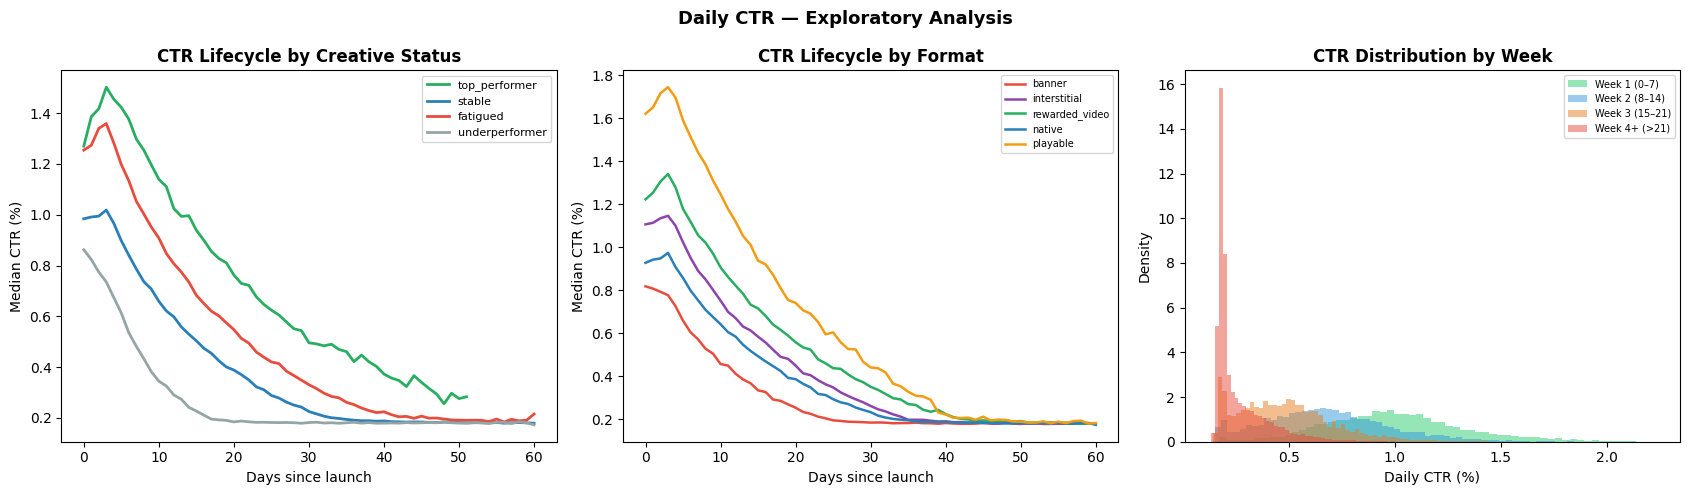

In [4]:
STATUS_COLORS = {
    'top_performer': '#27AE60', 'stable': '#2980B9',
    'fatigued': '#E74C3C', 'underperformer': '#95A5A6',
}
FORMAT_COLORS = {
    'banner': '#E74C3C', 'interstitial': '#8E44AD',
    'rewarded_video': '#27AE60', 'native': '#2980B9', 'playable': '#F39C12',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: by status (up to day 60)
for status in ['top_performer', 'stable', 'fatigued', 'underperformer']:
    sub = daily[(daily['creative_status'] == status) & (daily['days_since_launch'] <= 60)]
    grp = sub.groupby('days_since_launch')['ctr'].median() * 100
    axes[0].plot(grp.index, grp.values, label=status, color=STATUS_COLORS[status], lw=2)
axes[0].set_xlabel('Days since launch')
axes[0].set_ylabel('Median CTR (%)')
axes[0].set_title('CTR Lifecycle by Creative Status', fontweight='bold')
axes[0].legend(fontsize=8)

# Panel 2: by format
for fmt, color in FORMAT_COLORS.items():
    sub = daily[(daily['format'] == fmt) & (daily['days_since_launch'] <= 60)]
    grp = sub.groupby('days_since_launch')['ctr'].median() * 100
    axes[1].plot(grp.index, grp.values, label=fmt, color=color, lw=1.8)
axes[1].set_xlabel('Days since launch')
axes[1].set_ylabel('Median CTR (%)')
axes[1].set_title('CTR Lifecycle by Format', fontweight='bold')
axes[1].legend(fontsize=7)

# Panel 3: weekly CTR distribution
week_bins  = [-1, 7, 14, 21, 999]
week_labels = ['Week 1 (0–7)', 'Week 2 (8–14)', 'Week 3 (15–21)', 'Week 4+ (>21)']
week_colors = ['#2ECC71', '#3498DB', '#E67E22', '#E74C3C']
daily['week_bucket'] = pd.cut(daily['days_since_launch'], bins=week_bins, labels=week_labels)
for wl, wc in zip(week_labels, week_colors):
    vals = daily[daily['week_bucket'] == wl]['ctr'].clip(0, 0.025) * 100
    axes[2].hist(vals, bins=60, alpha=0.5, label=wl, color=wc, density=True)
axes[2].set_xlabel('Daily CTR (%)')
axes[2].set_ylabel('Density')
axes[2].set_title('CTR Distribution by Week', fontweight='bold')
axes[2].legend(fontsize=7)

plt.suptitle('Daily CTR — Exploratory Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA}/ctr_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature engineering — temporal + lagged + exposure

We compute three groups of features, all **non-leaky** (only use information available before day t):

| Group | Features | Why |
|---|---|---|
| Temporal | `log_days`, `sqrt_days`, `days_sq`, `is_week1/2` | Capture the lifecycle curve shape |
| Lagged CTR | `ctr_lag1/2/3`, `ctr_roll3d`, `ctr_roll7d`, `max_ctr`, `ctr_vs_max` | The current level of performance and trend direction |
| Exposure | `log_imp_last7d`, `log_cum_imp`, `spend_vel_7d` | Saturation / frequency — the fatigue driver |
| Interactions | `novelty × log_days`, `clutter × log_days`, `gameplay × log_days` | Non-linear creative × lifecycle effects |

> **`ctr_vs_max`**: ratio of yesterday's CTR to the rolling peak so far. This is the most direct early-warning signal: when it drops below 0.5, the creative is decaying.

In [5]:
daily = daily.sort_values(['creative_id', 'days_since_launch']).reset_index(drop=True)

# --- Temporal ---
daily['log_days']  = np.log1p(daily['days_since_launch'])
daily['sqrt_days'] = np.sqrt(daily['days_since_launch'])
daily['days_sq']   = (daily['days_since_launch'] ** 2) / 1000.0
daily['is_week1']  = (daily['days_since_launch'] <= 7).astype(float)
daily['is_week2']  = ((daily['days_since_launch'] > 7) & (daily['days_since_launch'] <= 14)).astype(float)

# --- Lagged CTR (shift by 1 day → no leakage) ---
g = daily.groupby('creative_id')['ctr']
daily['ctr_lag1']      = g.shift(1)
daily['ctr_lag2']      = g.shift(2)
daily['ctr_lag3']      = g.shift(3)
daily['ctr_roll3d']    = g.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
daily['ctr_roll7d']    = g.transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
daily['max_ctr_so_far'] = g.transform(lambda x: x.shift(1).expanding().max())
daily['ctr_vs_max']    = (daily['ctr_lag1'] / daily['max_ctr_so_far'].clip(lower=1e-9)).clip(0, 2)

# 7-day CTR slope: positive = still rising, negative = decaying
def rolling_slope(s, w=7):
    vals = np.empty(len(s))
    arr  = s.values
    for i in range(len(arr)):
        chunk = arr[max(0, i-w):i]  # up to but not including current
        if len(chunk) >= 2:
            vals[i] = np.polyfit(np.arange(len(chunk), dtype=float), chunk, 1)[0]
        else:
            vals[i] = 0.0
    return vals

daily['ctr_slope_7d'] = daily.groupby('creative_id')['ctr'].transform(rolling_slope)

# --- Exposure ---
cum_imp = daily.groupby('creative_id')['impressions'].transform(lambda x: x.shift(1).cumsum().fillna(0))
daily['log_imp_last7d'] = np.log1p(daily['impressions_last_7d'])
daily['log_cum_imp']    = np.log1p(cum_imp)
daily['spend_vel_7d']   = (
    daily.groupby('creative_id')['spend_usd']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    .fillna(0)
)

# --- Interactions ---
daily['novelty_x_days']  = daily['novelty_score']  * daily['log_days']
daily['clutter_x_days']  = daily['clutter_score']  * daily['log_days']
daily['gameplay_x_days'] = daily['has_gameplay']   * daily['log_days']
daily['motion_x_days']   = daily['motion_score']   * daily['log_days']

# Fill NaN from lags (day 0 has no history)
LAG_COLS = ['ctr_lag1','ctr_lag2','ctr_lag3','ctr_roll3d','ctr_roll7d',
            'max_ctr_so_far','ctr_vs_max','ctr_slope_7d']
daily[LAG_COLS] = daily[LAG_COLS].fillna(0)

print('Features computed. Sample:')
print(daily[['days_since_launch','ctr','ctr_lag1','ctr_roll7d','max_ctr_so_far',
             'ctr_vs_max','log_imp_last7d']].head(15).round(5).to_string())

Features computed. Sample:
    days_since_launch      ctr  ctr_lag1  ctr_roll7d  max_ctr_so_far  ctr_vs_max  log_imp_last7d
0                   0  0.01130   0.00000     0.00000          0.0000     0.00000         0.00000
1                   1  0.00954   0.01130     0.01130          0.0113     1.00000        13.75413
2                   2  0.00861   0.00954     0.01042          0.0113     0.84450        14.14577
3                   3  0.00814   0.00861     0.00982          0.0113     0.76177        14.42920
4                   4  0.00651   0.00814     0.00940          0.0113     0.72070        14.60164
5                   5  0.00582   0.00651     0.00882          0.0113     0.57644        14.76132
6                   6  0.00460   0.00582     0.00832          0.0113     0.51526        14.91115
7                   7  0.00458   0.00460     0.00779          0.0113     0.40724        15.01374
8                   8  0.00359   0.00458     0.00683          0.0113     0.40545        14.80460
9  

## 5. Per-creative temporal train / test split (70/30)

For each creative we find the day at the 70th percentile of its observed days. Everything up to (and including) that day is **training**; everything after is **test**.

All training portions are stacked into a global train set; all test portions are stacked into a global test set. The LightGBM model is trained once on the global train set and evaluated per-creative on the test portions.

In [6]:
def get_split_day(group, frac=TRAIN_FRAC):
    days_sorted = sorted(group['days_since_launch'].unique())
    idx = max(0, int(len(days_sorted) * frac) - 1)
    return days_sorted[idx]

split_map = daily.groupby('creative_id').apply(get_split_day)
daily['split_day'] = daily['creative_id'].map(split_map)
daily['is_train']  = daily['days_since_launch'] <= daily['split_day']
daily['is_test']   = daily['days_since_launch'] >  daily['split_day']

# Summary
n_train = daily['is_train'].sum()
n_test  = daily['is_test'].sum()
print(f'Train rows : {n_train:,}  ({n_train/(n_train+n_test)*100:.1f}%)')
print(f'Test rows  : {n_test:,}  ({n_test/(n_train+n_test)*100:.1f}%)')
print(f'All {daily["creative_id"].nunique()} creatives contribute to both sets.')
print(f'\nSplit day stats (day at 70% of lifecycle):')
print(split_map.describe().round(1).to_string())

Train rows : 36,168  (69.1%)
Test rows  : 16,181  (30.9%)
All 1080 creatives contribute to both sets.

Split day stats (day at 70% of lifecycle):
count    1080.0
mean       32.5
std         6.2
min        18.0
25%        28.0
50%        32.0
75%        37.0
max        50.0


## 6. Parametric baseline — log-quadratic curve fit per creative

We fit one parametric curve per creative using only its **training days**.

**Model:**
```
log CTR(t) = a + b·log(t+1) + c·[log(t+1)]²
```
This is a second-degree polynomial in log-time, which can represent:
- `b > 0, c < 0` → rises then decays (inverted-U, the typical lifecycle)
- `b ≈ 0, c ≈ 0` → flat (stable creative)
- `b < 0`        → monotone decline (underperformer)

The baseline's predictions are then evaluated on the **test days** of each creative.

In [7]:
def log_quad_model(t, a, b, c):
    lt = np.log1p(np.asarray(t, dtype=float))
    return np.exp(np.clip(a + b * lt + c * lt ** 2, -15, 0))

def fit_per_creative(days, ctrs):
    if len(days) < 5:
        return None
    try:
        p0 = [np.log(max(ctrs.mean(), 1e-7)), 0.2, -0.05]
        popt, _ = curve_fit(
            log_quad_model, days, ctrs,
            p0=p0,
            bounds=([-20, -4, -4], [0, 4, 1]),
            maxfev=8000,
        )
        return popt
    except Exception:
        return [np.log(max(ctrs.mean(), 1e-7)), 0.0, 0.0]

param_fits   = {}
param_preds  = []   # (creative_id, day, actual_ctr, param_pred)

for cid, grp in daily.groupby('creative_id'):
    train = grp[grp['is_train']].sort_values('days_since_launch')
    test  = grp[grp['is_test']].sort_values('days_since_launch')

    params = fit_per_creative(train['days_since_launch'].values.astype(float), train['ctr'].values)
    param_fits[cid] = params

    if params is not None and len(test) > 0:
        preds = log_quad_model(test['days_since_launch'].values.astype(float), *params)
        for d, y, yp in zip(test['days_since_launch'].values, test['ctr'].values, preds):
            param_preds.append({'creative_id': cid, 'day': d, 'actual': y, 'param_pred': float(yp)})

param_df = pd.DataFrame(param_preds)

param_rmse = np.sqrt(mean_squared_error(param_df['actual'], param_df['param_pred']))
param_mae  = mean_absolute_error(param_df['actual'], param_df['param_pred'])
param_r2   = r2_score(param_df['actual'], param_df['param_pred'])

print('PARAMETRIC BASELINE — test set performance:')
print(f'  RMSE : {param_rmse:.6f}  ({param_rmse*100:.4f}% CTR units)')
print(f'  MAE  : {param_mae:.6f}  ({param_mae*100:.4f}% CTR units)')
print(f'  R²   : {param_r2:.4f}')

PARAMETRIC BASELINE — test set performance:
  RMSE : 0.000662  (0.0662% CTR units)
  MAE  : 0.000568  (0.0568% CTR units)
  R²   : 0.5292


## 7. LightGBM feature matrix

We one-hot-encode the categorical variables so SHAP can interpret them cleanly, then combine with all numeric features into a single feature matrix.

In [8]:
STATIC_CATS = ['vertical', 'format', 'dominant_color', 'emotional_tone',
               'hook_type', 'language', 'target_os', 'kpi_goal', 'objective']

STATIC_NUMS = [
    'text_density', 'readability_score', 'brand_visibility_score',
    'clutter_score', 'novelty_score', 'motion_score',
    'faces_count', 'product_count', 'duration_sec', 'copy_length_chars',
    'has_price', 'has_discount_badge', 'has_gameplay', 'has_ugc_style',
]

TEMPORAL_FEATS = ['days_since_launch', 'log_days', 'sqrt_days', 'days_sq', 'is_week1', 'is_week2']
LAG_FEATS      = ['ctr_lag1', 'ctr_lag2', 'ctr_lag3', 'ctr_roll3d', 'ctr_roll7d',
                  'max_ctr_so_far', 'ctr_vs_max', 'ctr_slope_7d']
EXPOSURE_FEATS = ['log_imp_last7d', 'log_cum_imp', 'spend_vel_7d']
INTERACT_FEATS = ['novelty_x_days', 'clutter_x_days', 'gameplay_x_days', 'motion_x_days']

# One-hot encode categoricals
model_df = daily.copy()
for col in STATIC_CATS:
    model_df[col] = model_df[col].fillna('unknown')
# Preserve original labels before OHE drops the columns
model_df['_vertical'] = model_df['vertical']
model_df['_format']   = model_df['format']
model_df = pd.get_dummies(model_df, columns=STATIC_CATS, drop_first=True, dtype=float)

CAT_DUMMIES = [c for c in model_df.columns
               if any(c.startswith(cat + '_') for cat in STATIC_CATS)]

ALL_FEATURES = STATIC_NUMS + TEMPORAL_FEATS + LAG_FEATS + EXPOSURE_FEATS + INTERACT_FEATS + CAT_DUMMIES

# Fill any remaining NaN
model_df[ALL_FEATURES] = model_df[ALL_FEATURES].fillna(0)

print(f'Feature matrix: {len(ALL_FEATURES)} features')
print(f'  Static numeric  : {len(STATIC_NUMS)}')
print(f'  Temporal        : {len(TEMPORAL_FEATS)}')
print(f'  Lagged CTR      : {len(LAG_FEATS)}')
print(f'  Exposure        : {len(EXPOSURE_FEATS)}')
print(f'  Interactions    : {len(INTERACT_FEATS)}')
print(f'  One-hot dummies : {len(CAT_DUMMIES)}')

Feature matrix: 99 features
  Static numeric  : 14
  Temporal        : 6
  Lagged CTR      : 8
  Exposure        : 3
  Interactions    : 4
  One-hot dummies : 64


## 8. Global train / test arrays

Stack all creatives' training and test portions into global arrays. Within-creative ordering is preserved (LightGBM doesn't require ordering, but it matters for the per-creative evaluation).

In [9]:
train_df = model_df[model_df['is_train']].copy()
test_df  = model_df[model_df['is_test']].copy()

X_train = train_df[ALL_FEATURES]
y_train = train_df['ctr']
X_test  = test_df[ALL_FEATURES]
y_test  = test_df['ctr']

print(f'Train: {X_train.shape[0]:,} rows × {X_train.shape[1]} features')
print(f'Test : {X_test.shape[0]:,} rows × {X_test.shape[1]} features')
print(f'Train CTR mean: {y_train.mean()*100:.4f}%')
print(f'Test  CTR mean: {y_test.mean()*100:.4f}%')

Train: 36,168 rows × 99 features
Test : 16,181 rows × 99 features
Train CTR mean: 0.5857%
Test  CTR mean: 0.2263%


## 9. LightGBM — training with early stopping

**Objective:** `regression_l1` (MAE) — more robust than MSE to CTR outliers (very high-CTR days) and leads to tighter median predictions.

**Early stopping:** we hold out a random 15% of the training data as a validation set *purely for stopping* (not for final evaluation — that uses the per-creative test split from Section 5).

LightGBM's `num_leaves=127` with `min_child_samples=30` prevents overfitting to individual creatives. `feature_fraction` and `bagging_fraction` add regularisation via stochastic feature/row subsampling.

In [10]:
# Hold-out 15% of train rows for early stopping (random, not per-creative)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

lgb_tr  = lgb.Dataset(X_tr,  label=y_tr)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_tr)

params = {
    'objective':         'regression_l1',
    'metric':            'rmse',
    'num_leaves':        127,
    'learning_rate':     0.02,
    'feature_fraction':  0.75,
    'bagging_fraction':  0.80,
    'bagging_freq':      5,
    'min_child_samples': 30,
    'reg_alpha':         0.05,
    'reg_lambda':        0.10,
    'verbose':          -1,
    'random_state':      42,
}

model = lgb.train(
    params,
    lgb_tr,
    num_boost_round=5000,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=500),
    ],
)

print(f'\nBest iteration       : {model.best_iteration}')
print(f'Best validation RMSE : {model.best_score["valid_0"]["rmse"]:.6f}')

[500]	valid_0's rmse: 0.000480213
[1000]	valid_0's rmse: 0.000478306
[1500]	valid_0's rmse: 0.000477555

Best iteration       : 1645
Best validation RMSE : 0.000477


## 10. Test set evaluation — global metrics & comparison

We evaluate both the LightGBM model and the parametric baseline on the **same** held-out test rows (last 30% of each creative's days).

  MODEL COMPARISON — held-out test set (last 30% per creative)
  Metric      Parametric baseline     LightGBM Δ (%)
----------------------------------------------------------
  RMSE                   0.000662     0.000205   +69.0%
  MAE                    0.000568     0.000148   +73.9%
  R²                       0.5292       0.9547   +0.4255


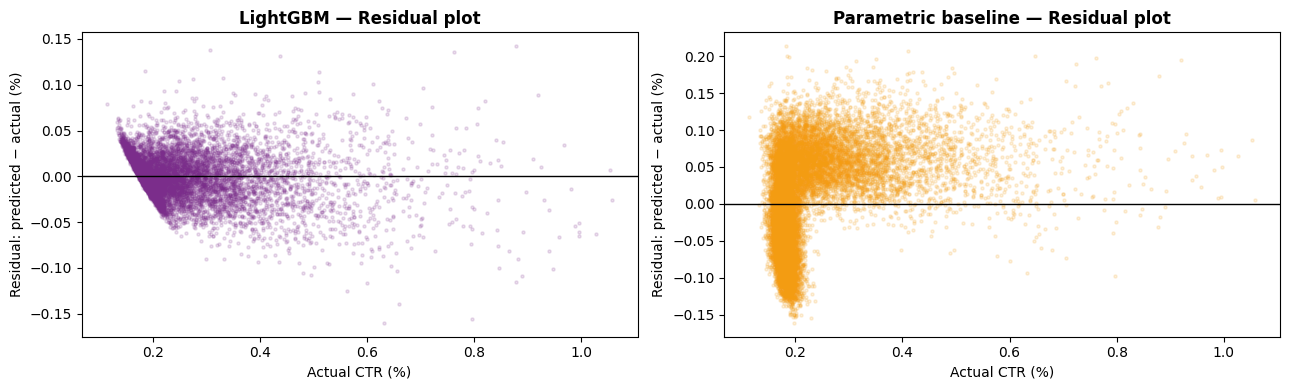

In [11]:
y_pred_test = np.clip(model.predict(X_test), 0, None)

lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
lgb_mae  = mean_absolute_error(y_test, y_pred_test)
lgb_r2   = r2_score(y_test, y_pred_test)

print('=' * 58)
print(f'  MODEL COMPARISON — held-out test set (last 30% per creative)')
print('=' * 58)
print(f'  {"Metric":<10} {"Parametric baseline":>20} {"LightGBM":>12} {"Δ (%)"}' )
print('-' * 58)
print(f'  {"RMSE":<10} {param_rmse:>20.6f} {lgb_rmse:>12.6f}   {(1-lgb_rmse/param_rmse)*100:+.1f}%')
print(f'  {"MAE":<10} {param_mae:>20.6f} {lgb_mae:>12.6f}   {(1-lgb_mae/param_mae)*100:+.1f}%')
print(f'  {"R²":<10} {param_r2:>20.4f} {lgb_r2:>12.4f}   {lgb_r2 - param_r2:+.4f}')
print('=' * 58)

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, y_pred, label, color in [
    (axes[0], y_pred_test,           'LightGBM', '#7B2D8B'),
    (axes[1], param_df['param_pred'], 'Parametric baseline', '#F39C12'),
]:
    y_true_plot = y_test.values if label == 'LightGBM' else param_df['actual'].values
    resid = y_pred - y_true_plot
    ax.scatter(y_true_plot * 100, resid * 100, alpha=0.15, s=5, color=color)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Actual CTR (%)')
    ax.set_ylabel('Residual: predicted − actual (%)')
    ax.set_title(f'{label} — Residual plot', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA}/ctr_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Per-creative R² distribution

Global metrics can hide the per-creative spread. Here we compute the R² for **each creative's test period** individually and compare LightGBM vs the parametric baseline.

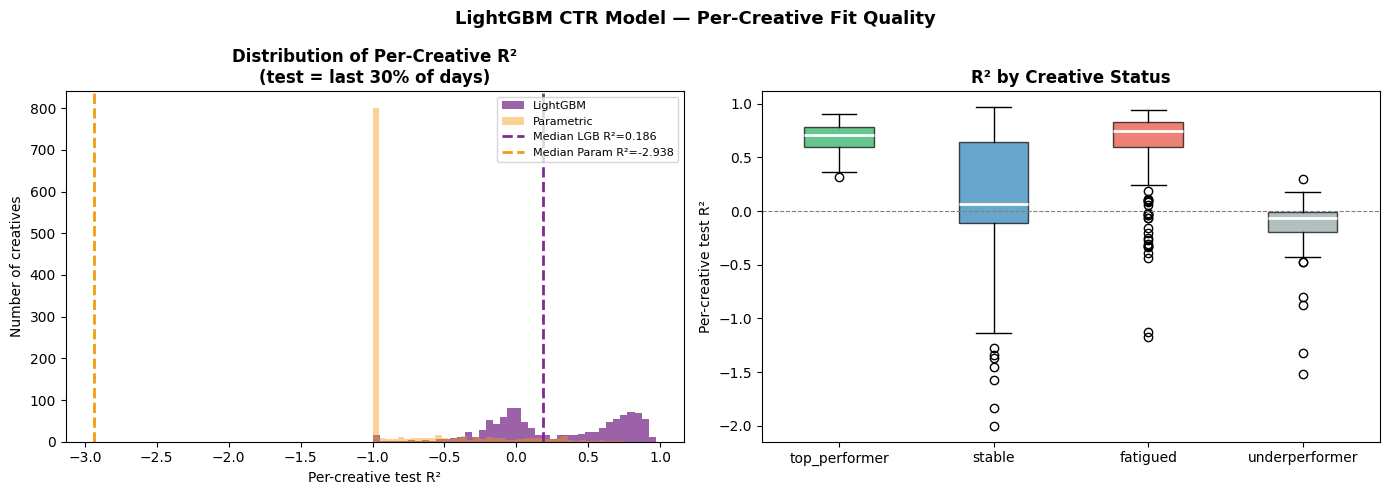

Creatives with R² ≥ 0.70 : 295 / 1080  (27.3%)
Creatives with R² ≥ 0.50 : 447 / 1080
Median per-creative R²   : 0.186


In [12]:
test_df = test_df.copy()
test_df['lgb_pred'] = y_pred_test

# Parametric predictions indexed by (creative_id, day)
param_lookup = (
    param_df
    .set_index(['creative_id', 'day'])['param_pred']
    .to_dict()
)
test_df['param_pred'] = test_df.apply(
    lambda r: param_lookup.get((r['creative_id'], r['days_since_launch']), np.nan), axis=1
)

per_creative = []
for cid, grp in test_df.groupby('creative_id'):
    valid = grp.dropna(subset=['param_pred'])
    r2_lgb   = r2_score(grp['ctr'],    grp['lgb_pred'])      if len(grp)   >= 3 else np.nan
    r2_param = r2_score(valid['ctr'],  valid['param_pred'])   if len(valid) >= 3 else np.nan
    per_creative.append({
        'creative_id': cid,
        'n_test_days': len(grp),
        'r2_lgb': r2_lgb,
        'r2_param': r2_param,
        'rmse_lgb': np.sqrt(mean_squared_error(grp['ctr'], grp['lgb_pred'])),
        'vertical': grp['_vertical'].iloc[0],
        'format': grp['_format'].iloc[0],
        'creative_status': grp['creative_status'].iloc[0],
    })

metrics_df = pd.DataFrame(per_creative)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(metrics_df['r2_lgb'].clip(-1, 1),   bins=40, alpha=0.75, color='#7B2D8B', label='LightGBM')
axes[0].hist(metrics_df['r2_param'].clip(-1, 1),  bins=40, alpha=0.45, color='#F39C12', label='Parametric')
axes[0].axvline(metrics_df['r2_lgb'].median(),   color='#7B2D8B', lw=2, ls='--',
                label=f'Median LGB R²={metrics_df["r2_lgb"].median():.3f}')
axes[0].axvline(metrics_df['r2_param'].median(), color='#F39C12', lw=2, ls='--',
                label=f'Median Param R²={metrics_df["r2_param"].median():.3f}')
axes[0].set_xlabel('Per-creative test R²')
axes[0].set_ylabel('Number of creatives')
axes[0].set_title('Distribution of Per-Creative R²\n(test = last 30% of days)', fontweight='bold')
axes[0].legend(fontsize=8)

# Box by creative status
status_order  = ['top_performer', 'stable', 'fatigued', 'underperformer']
status_colors = ['#27AE60', '#2980B9', '#E74C3C', '#95A5A6']
bdata = [metrics_df[metrics_df['creative_status'] == s]['r2_lgb'].dropna() for s in status_order]
bp = axes[1].boxplot(bdata, labels=status_order, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, c in zip(bp['boxes'], status_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_ylabel('Per-creative test R²')
axes[1].set_title('R² by Creative Status', fontweight='bold')

plt.suptitle('LightGBM CTR Model — Per-Creative Fit Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA}/ctr_r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

good = (metrics_df['r2_lgb'] >= 0.7).sum()
total = len(metrics_df)
print(f'Creatives with R² ≥ 0.70 : {good} / {total}  ({good/total*100:.1f}%)')
print(f'Creatives with R² ≥ 0.50 : {(metrics_df["r2_lgb"]>=0.5).sum()} / {total}')
print(f'Median per-creative R²   : {metrics_df["r2_lgb"].median():.3f}')

## 12. CTR curve visualisation — 12 example creatives (3×4 grid)

The payoff: predicted curves vs. reality. Each panel shows:
- **Gray dots** — raw daily CTR (noisy).
- **Black line** — 3-day centred smoothed actual CTR.
- **Blue line** — LightGBM predictions on the *training* portion.
- **Red line** — LightGBM predictions on the *test* portion (held-out).
- **Orange dashed** — parametric baseline (fitted on training days).
- **Vertical gray dotted** — 70/30 train/test split.
- **Vertical red solid** — Smadex `fatigue_day` label (if fatigued).

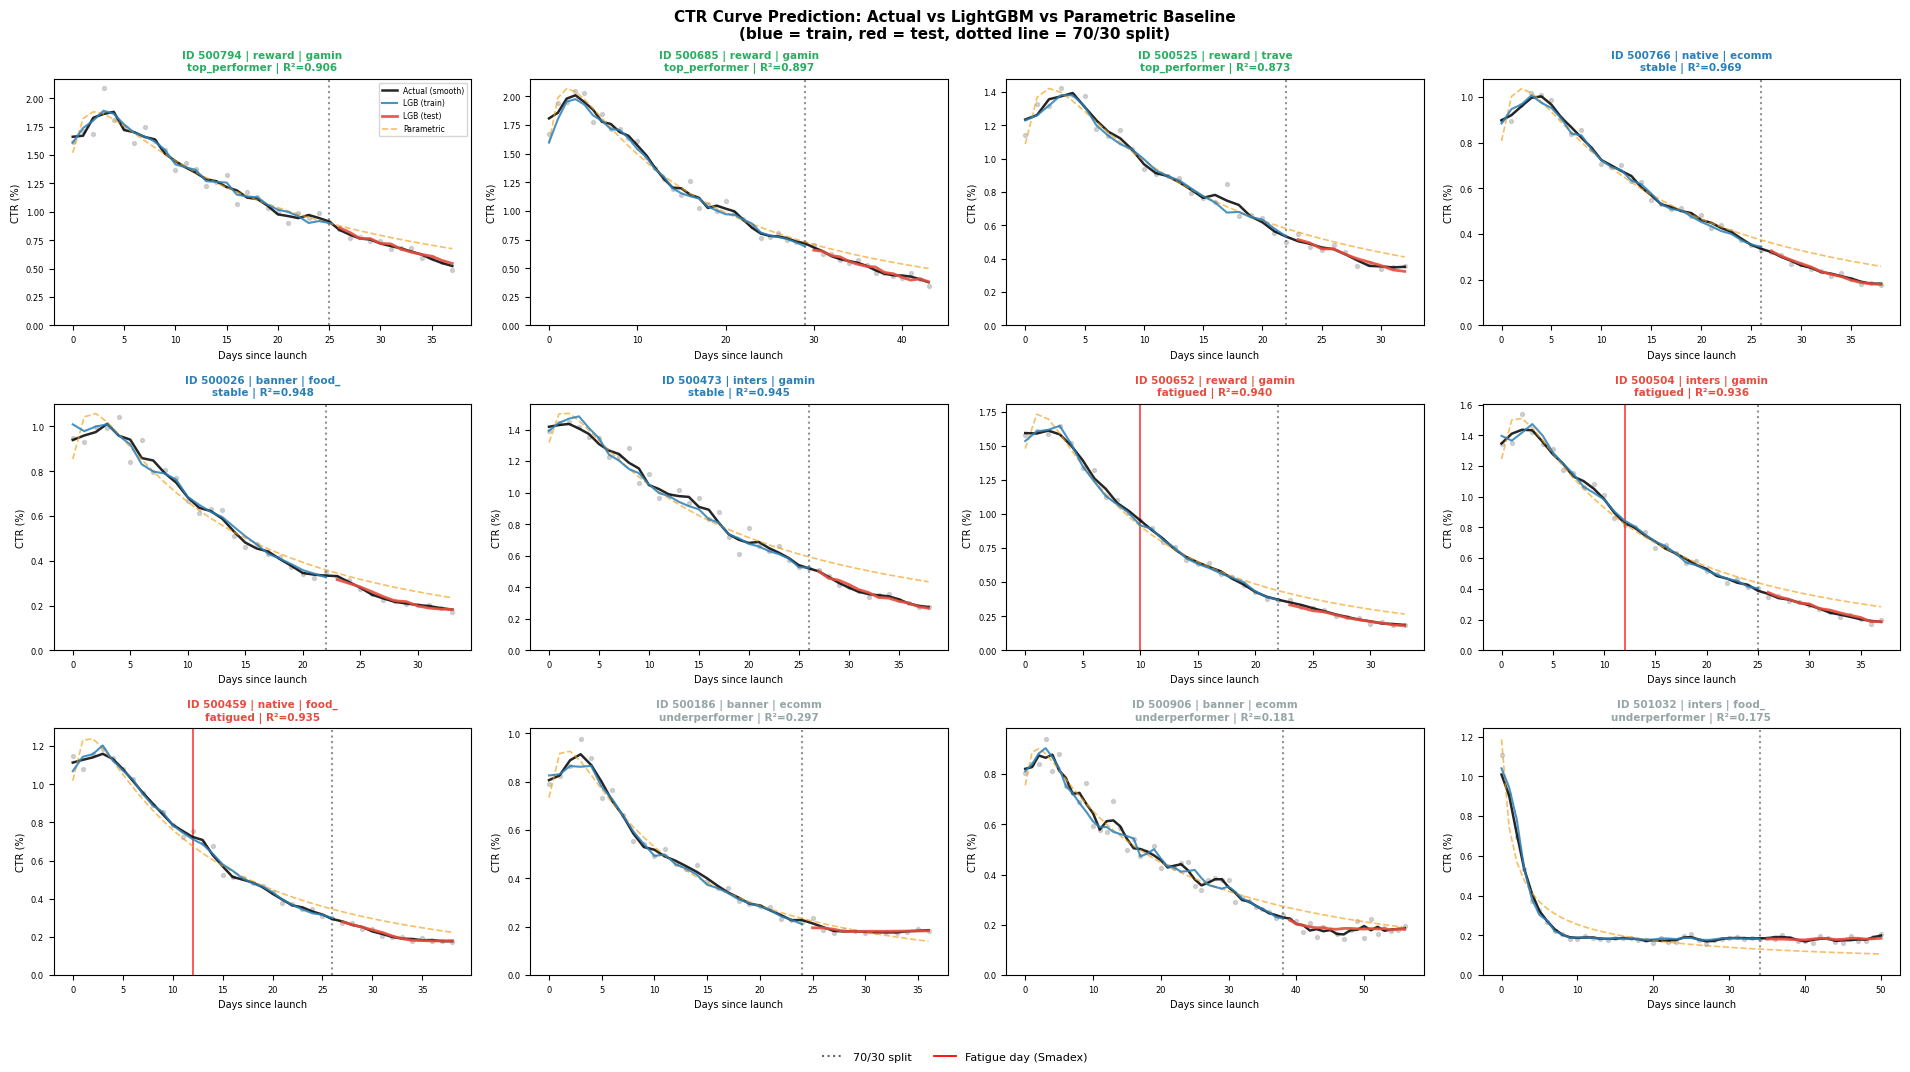

In [13]:
# Select 3 creatives per status with enough test days and decent fit
sample_ids = []
for status in ['top_performer', 'stable', 'fatigued', 'underperformer']:
    cands = (
        metrics_df[metrics_df['creative_status'] == status]
        .sort_values('r2_lgb', ascending=False)
        .head(3)['creative_id']
        .tolist()
    )
    sample_ids.extend(cands)

n_cols, n_rows = 4, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.8, n_rows * 3.6))
axes_flat = axes.flatten()

for idx, cid in enumerate(sample_ids[:n_cols * n_rows]):
    ax = axes_flat[idx]
    cdata    = model_df[model_df['creative_id'] == cid].sort_values('days_since_launch')
    split_d  = split_map.get(cid)
    status   = cdata['creative_status'].iloc[0]
    fat_d    = cdata['fatigue_day'].iloc[0]

    # Raw CTR
    ax.scatter(cdata['days_since_launch'], cdata['ctr'] * 100,
               color='#AAAAAA', s=8, alpha=0.5, zorder=2)
    # Smoothed actual
    ax.plot(cdata['days_since_launch'], cdata['ctr_smooth'] * 100,
            color='black', lw=1.8, alpha=0.85, label='Actual (smooth)', zorder=3)

    # LightGBM predictions
    train_sub = cdata[cdata['is_train']]
    test_sub  = cdata[cdata['is_test']]
    if len(train_sub) > 0:
        tr_pred = np.clip(model.predict(train_sub[ALL_FEATURES]), 0, None)
        ax.plot(train_sub['days_since_launch'], tr_pred * 100,
                color='#2980B9', lw=1.5, alpha=0.85, label='LGB (train)', zorder=4)
    if len(test_sub) > 0:
        te_pred = np.clip(model.predict(test_sub[ALL_FEATURES]), 0, None)
        ax.plot(test_sub['days_since_launch'], te_pred * 100,
                color='#E74C3C', lw=2.0, alpha=0.90, label='LGB (test)', zorder=5)

    # Parametric baseline
    params = param_fits.get(cid)
    if params is not None:
        all_days = cdata['days_since_launch'].values.astype(float)
        ax.plot(all_days, log_quad_model(all_days, *params) * 100,
                color='#F39C12', lw=1.2, ls='--', alpha=0.65, label='Parametric', zorder=3)

    # Annotations
    if split_d is not None:
        ax.axvline(split_d, color='#666666', ls=':', lw=1.5, alpha=0.7)
    if not pd.isna(fat_d):
        ax.axvline(fat_d, color='red', ls='-', lw=1.3, alpha=0.7)

    r2 = metrics_df.loc[metrics_df['creative_id'] == cid, 'r2_lgb'].values
    r2_str = f'R²={r2[0]:.3f}' if len(r2) else ''
    sc = STATUS_COLORS.get(status, 'black')
    ax.set_title(
        f'ID {cid} | {cdata["_format"].iloc[0][:6]} | {cdata["_vertical"].iloc[0][:5]}\n'
        f'{status} | {r2_str}',
        fontsize=7.5, color=sc, fontweight='bold'
    )
    ax.set_xlabel('Days since launch', fontsize=7)
    ax.set_ylabel('CTR (%)', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_ylim(bottom=0)
    if idx == 0:
        ax.legend(fontsize=5.5, loc='upper right')

# Legend for annotations
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='#666666', ls=':', lw=1.5, label='70/30 split'),
    Line2D([0],[0], color='red',     ls='-', lw=1.3, label='Fatigue day (Smadex)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=8, frameon=False)

plt.suptitle(
    'CTR Curve Prediction: Actual vs LightGBM vs Parametric Baseline\n'
    '(blue = train, red = test, dotted line = 70/30 split)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{DATA}/ctr_curves_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Error analysis — which creative types are hardest to predict?

TOP 5 BEST-PREDICTED (test R²):
 creative_id creative_status      vertical         format  r2_lgb  rmse_lgb  n_test_days
      500766          stable     ecommerce         native  0.9692    0.0001           12
      500026          stable food_delivery         banner  0.9484    0.0001           11
      500473          stable        gaming   interstitial  0.9449    0.0002           12
      500319          stable entertainment   interstitial  0.9445    0.0001           13
      500652        fatigued        gaming rewarded_video  0.9399    0.0001           11

TOP 5 HARDEST TO PREDICT (test R²):
 creative_id creative_status      vertical         format  r2_lgb  rmse_lgb  n_test_days
      500121          stable       fintech         banner -2.0007    0.0001           18
      500032          stable entertainment   interstitial -1.8368    0.0002           15
      500761          stable        gaming rewarded_video -1.5769    0.0002           20
      501034  underperformer food_deliver

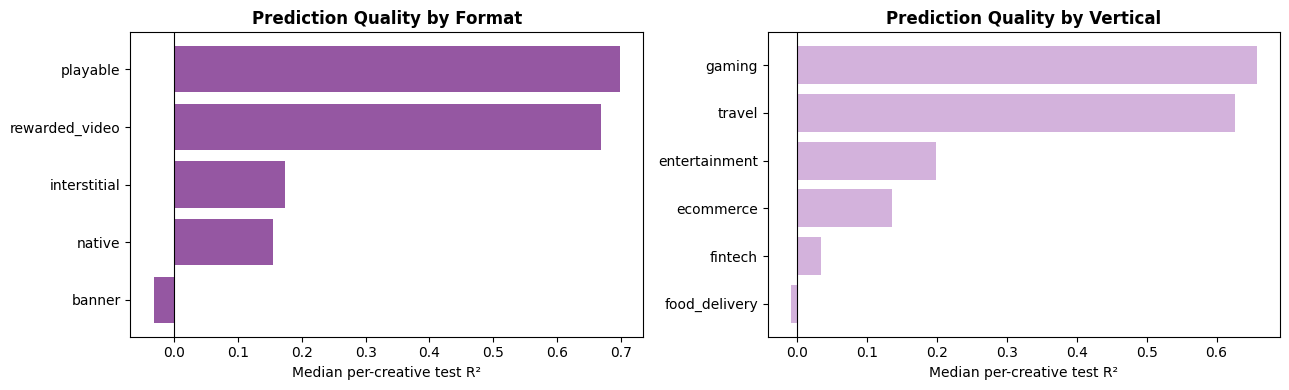

In [14]:
print('TOP 5 BEST-PREDICTED (test R²):')
print(metrics_df.nlargest(5, 'r2_lgb')[['creative_id','creative_status','vertical','format','r2_lgb','rmse_lgb','n_test_days']].round(4).to_string(index=False))
print()
print('TOP 5 HARDEST TO PREDICT (test R²):')
print(metrics_df.nsmallest(5, 'r2_lgb')[['creative_id','creative_status','vertical','format','r2_lgb','rmse_lgb','n_test_days']].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

r2_fmt  = metrics_df.groupby('format')['r2_lgb'].median().sort_values()
r2_vert = metrics_df.groupby('vertical')['r2_lgb'].median().sort_values()

axes[0].barh(r2_fmt.index, r2_fmt.values, color='#7B2D8B', alpha=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Median per-creative test R²')
axes[0].set_title('Prediction Quality by Format', fontweight='bold')

axes[1].barh(r2_vert.index, r2_vert.values, color='#C89FD4', alpha=0.8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Median per-creative test R²')
axes[1].set_title('Prediction Quality by Vertical', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA}/ctr_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. SHAP analysis — what drives the CTR prediction?

We use `shap.TreeExplainer` (TreeSHAP) to decompose predictions into per-feature contributions. On a sample of 2,000 test rows for speed.

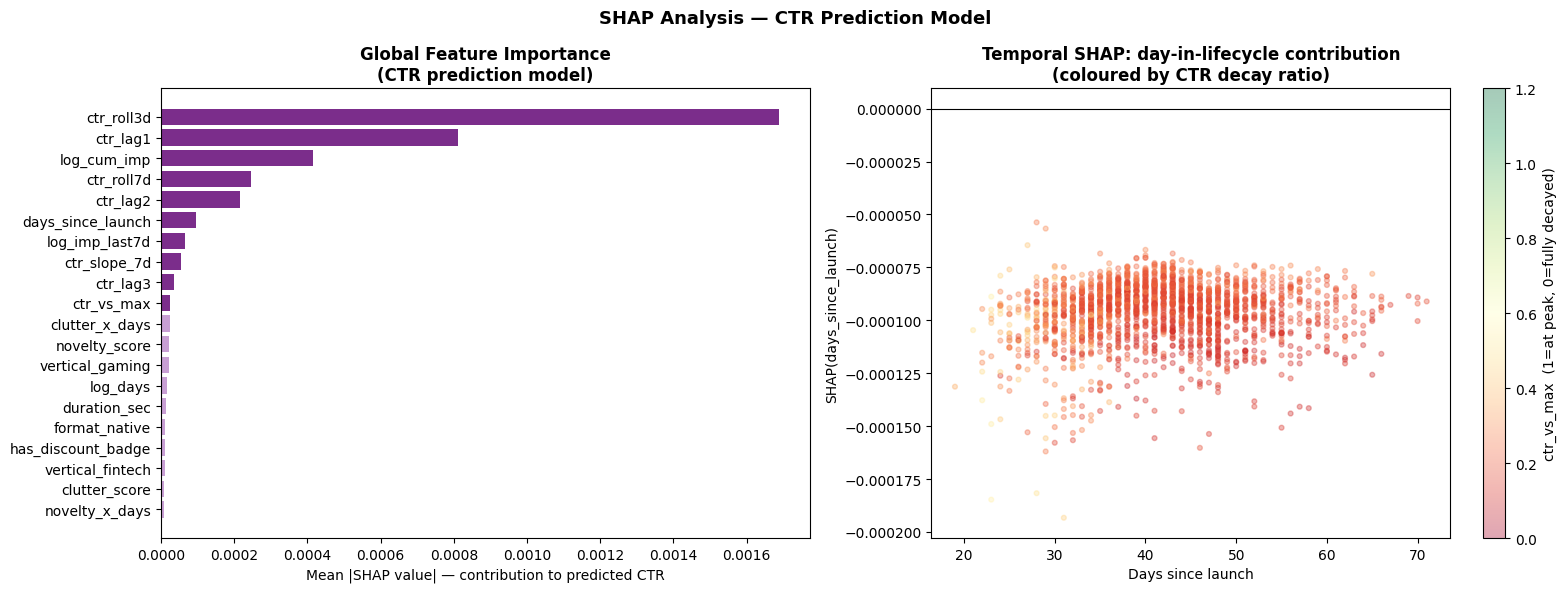

In [15]:
sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
meta_sample = test_df.iloc[sample_idx].reset_index(drop=True)

explainer_ctr = shap.TreeExplainer(model)
shap_vals     = explainer_ctr.shap_values(X_sample)  # (n_samples, n_features)

# Global bar: top 20 features by mean |SHAP|
mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=X_sample.columns).sort_values(ascending=True)
top20 = mean_abs.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top20.index, top20.values,
             color=['#7B2D8B' if v > top20.median() else '#C89FD4' for v in top20.values])
axes[0].set_xlabel('Mean |SHAP value| — contribution to predicted CTR')
axes[0].set_title('Global Feature Importance\n(CTR prediction model)', fontweight='bold')

# Temporal SHAP: how does the model use days_since_launch over the lifecycle?
shap_df = pd.DataFrame(shap_vals, columns=X_sample.columns)
sc = axes[1].scatter(
    meta_sample['days_since_launch'],
    shap_df['days_since_launch'],
    c=X_sample['ctr_vs_max'],
    cmap='RdYlGn', alpha=0.35, s=12, vmin=0, vmax=1.2,
)
plt.colorbar(sc, ax=axes[1], label='ctr_vs_max  (1=at peak, 0=fully decayed)')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Days since launch')
axes[1].set_ylabel('SHAP(days_since_launch)')
axes[1].set_title('Temporal SHAP: day-in-lifecycle contribution\n(coloured by CTR decay ratio)', fontweight='bold')

plt.suptitle('SHAP Analysis — CTR Prediction Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA}/ctr_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Phase-level SHAP — what drives CTR at each lifecycle stage?

We split test rows into three lifecycle phases and compute the top feature contributions in each phase:
- **Early (0–7d):** novelty and format dominate.
- **Peak (8–14d):** lagged CTR and exposure volume take over.
- **Late (15d+):** decay features (`ctr_vs_max`, `ctr_slope_7d`) and clutter matter most.

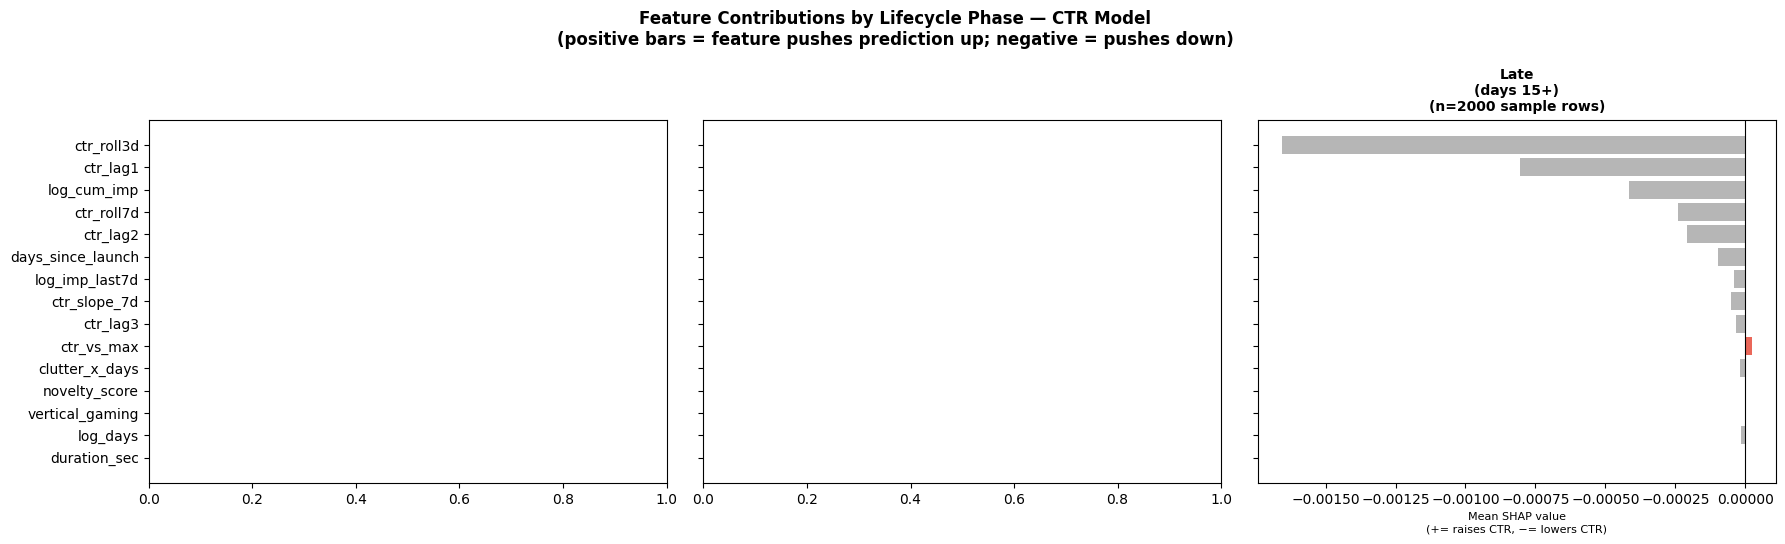

In [16]:
PHASES = {
    'Early\n(days 0–7)':  meta_sample['days_since_launch'] <= 7,
    'Peak\n(days 8–14)': (meta_sample['days_since_launch'] > 7) & (meta_sample['days_since_launch'] <= 14),
    'Late\n(days 15+)':   meta_sample['days_since_launch'] > 14,
}

# Fixed top-15 features (by global importance) for comparison across phases
top15_feats = mean_abs.tail(15).index.tolist()
feat_idx    = [list(X_sample.columns).index(f) for f in top15_feats]

PHASE_COLORS = {'Early\n(days 0–7)': '#27AE60', 'Peak\n(days 8–14)': '#F39C12', 'Late\n(days 15+)': '#E74C3C'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for ax, (phase_name, mask) in zip(axes, PHASES.items()):
    mask_arr = mask.values
    if mask_arr.sum() < 5:
        continue
    phase_shap = shap_vals[np.where(mask_arr)[0]][:, feat_idx]  # (n_phase, n_feats)
    mean_phase = phase_shap.mean(axis=0)                        # signed: + = raises CTR, - = lowers CTR

    bar_colors = [PHASE_COLORS[phase_name] if v >= 0 else '#AAAAAA' for v in mean_phase]
    ax.barh(top15_feats, mean_phase, color=bar_colors, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{phase_name}\n(n={mask_arr.sum()} sample rows)', fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean SHAP value\n(+= raises CTR, −= lowers CTR)', fontsize=8)

plt.suptitle(
    'Feature Contributions by Lifecycle Phase — CTR Model\n'
    '(positive bars = feature pushes prediction up; negative = pushes down)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{DATA}/ctr_shap_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Model-derived fatigue signal

We use the full predicted CTR curve (train + test) to derive a **data-driven fatigue signal**: the first day when predicted CTR drops below 50% of the creative's predicted peak CTR.

We then compare this predicted fatigue day with the Smadex `fatigue_day` label for all fatigued creatives. High correlation validates that the CTR model is learning the same phenomenon that Smadex labels as fatigue.

Fatigued creatives compared: 199
  Pearson  r = 0.879  (p=0.0000)
  Spearman r = 0.899
  MAE on fatigue day estimate: 4.7 days



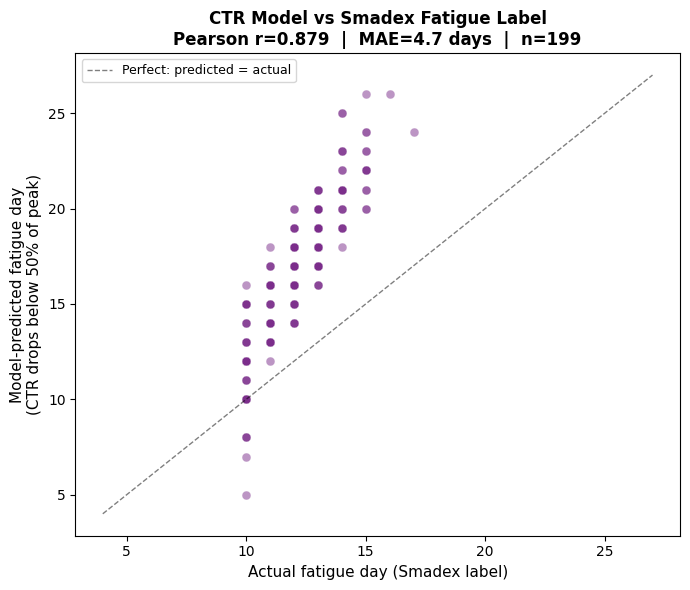

In [17]:
from scipy.stats import pearsonr, spearmanr

# Predict CTR for ALL in-scope rows (train + test)
model_df_all = model_df.copy()
model_df_all['lgb_pred_ctr'] = np.clip(model.predict(model_df_all[ALL_FEATURES]), 0, None)

# Smooth predictions per creative to reduce noise in peak/fatigue detection
model_df_all['lgb_pred_smooth'] = (
    model_df_all.groupby('creative_id')['lgb_pred_ctr']
    .transform(lambda x: x.rolling(3, center=True, min_periods=1).mean())
)

derived_fatigue = []
for cid, grp in model_df_all.groupby('creative_id'):
    grp   = grp.sort_values('days_since_launch')
    days  = grp['days_since_launch'].values
    pred  = grp['lgb_pred_smooth'].values

    peak_idx  = np.argmax(pred)
    peak_day  = days[peak_idx]
    peak_ctr  = pred[peak_idx]

    # First day after peak where predicted CTR < 50% of predicted peak
    post_peak = (days > peak_day) & (pred < 0.50 * peak_ctr)
    pred_fat  = int(days[post_peak][0]) if post_peak.any() else None

    derived_fatigue.append({
        'creative_id':        cid,
        'creative_status':    grp['creative_status'].iloc[0],
        'actual_fatigue_day': grp['fatigue_day'].iloc[0],
        'pred_peak_day':      int(peak_day),
        'pred_peak_ctr':      peak_ctr,
        'pred_fatigue_day':   pred_fat,
        'vertical':           grp['_vertical'].iloc[0],
        'format':             grp['_format'].iloc[0],
    })

fat_df = pd.DataFrame(derived_fatigue)
fat_fat = fat_df[
    (fat_df['creative_status'] == 'fatigued') &
    fat_df['actual_fatigue_day'].notna() &
    fat_df['pred_fatigue_day'].notna()
].copy()

fat_fat['actual_fatigue_day'] = fat_fat['actual_fatigue_day'].astype(float)
fat_fat['pred_fatigue_day']   = fat_fat['pred_fatigue_day'].astype(float)

pearson_r, pearson_p = pearsonr(fat_fat['actual_fatigue_day'], fat_fat['pred_fatigue_day'])
spearman_r, _        = spearmanr(fat_fat['actual_fatigue_day'], fat_fat['pred_fatigue_day'])
mae_fatigue = mean_absolute_error(fat_fat['actual_fatigue_day'], fat_fat['pred_fatigue_day'])

print(f'Fatigued creatives compared: {len(fat_fat)}')
print(f'  Pearson  r = {pearson_r:.3f}  (p={pearson_p:.4f})')
print(f'  Spearman r = {spearman_r:.3f}')
print(f'  MAE on fatigue day estimate: {mae_fatigue:.1f} days')
print()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(fat_fat['actual_fatigue_day'], fat_fat['pred_fatigue_day'],
           alpha=0.5, s=40, color='#7B2D8B', edgecolors='white', linewidths=0.3)
lim = [min(fat_fat['actual_fatigue_day'].min(), fat_fat['pred_fatigue_day'].min()) - 1,
       max(fat_fat['actual_fatigue_day'].max(), fat_fat['pred_fatigue_day'].max()) + 1]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.5, label='Perfect: predicted = actual')
ax.set_xlabel('Actual fatigue day (Smadex label)', fontsize=11)
ax.set_ylabel('Model-predicted fatigue day\n(CTR drops below 50% of peak)', fontsize=11)
ax.set_title(
    f'CTR Model vs Smadex Fatigue Label\n'
    f'Pearson r={pearson_r:.3f}  |  MAE={mae_fatigue:.1f} days  |  n={len(fat_fat)}',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA}/predicted_vs_actual_fatigue_day.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Export predictions

Save the per-creative-day predicted CTR and the derived fatigue signals for downstream use (dashboard, survival analysis notebooks).

In [18]:
# Full CTR predictions
export_ctr = model_df_all[[
    'creative_id', 'days_since_launch', 'ctr', 'lgb_pred_ctr', 'lgb_pred_smooth',
    'creative_status', 'fatigue_day', '_vertical', '_format', 'is_train', 'is_test'
]].copy().rename(columns={'_vertical': 'vertical', '_format': 'format'})
export_ctr.to_csv(f'{DATA}/ctr_predictions.csv', index=False)

# Derived fatigue signals
fat_df.to_csv(f'{DATA}/predicted_fatigue_signals.csv', index=False)

# Per-creative evaluation metrics
metrics_df.to_csv(f'{DATA}/ctr_model_metrics.csv', index=False)

print(f'Exported:')
print(f'  ctr_predictions.csv          — {len(export_ctr):,} rows')
print(f'  predicted_fatigue_signals.csv — {len(fat_df):,} creatives')
print(f'  ctr_model_metrics.csv         — {len(metrics_df):,} creatives')
print()

# Final summary table
print('FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Global test RMSE                  : {lgb_rmse:.6f}')
print(f'  Global test R²                    : {lgb_r2:.4f}')
print(f'  Median per-creative test R²       : {metrics_df["r2_lgb"].median():.3f}')
print(f'  Creatives with R² ≥ 0.70          : {(metrics_df["r2_lgb"]>=0.7).sum()} / {len(metrics_df)}')
print(f'  Fatigue day MAE (fatigued only)   : {mae_fatigue:.1f} days')
print(f'  Fatigue day Pearson r             : {pearson_r:.3f}')
print('=' * 55)

Exported:
  ctr_predictions.csv          — 52,349 rows
  predicted_fatigue_signals.csv — 1,080 creatives
  ctr_model_metrics.csv         — 1,080 creatives

FINAL MODEL SUMMARY
  Global test RMSE                  : 0.000205
  Global test R²                    : 0.9547
  Median per-creative test R²       : 0.186
  Creatives with R² ≥ 0.70          : 295 / 1080
  Fatigue day MAE (fatigued only)   : 4.7 days
  Fatigue day Pearson r             : 0.879


## Summary

| Step | What was built | Key output |
|---|---|---|
| 1–2 | Creative × day aggregation + metadata join | Clean daily CTR series |
| 3 | EDA: lifecycle patterns by status/format | `ctr_eda.png` |
| 4 | 25+ features: temporal, lag, exposure, interaction | Feature matrix |
| 5 | Per-creative 70/30 temporal split | Train/test flag per row |
| 6 | Log-quadratic baseline fit per creative | Parametric benchmark |
| 7–9 | LightGBM global model with early stopping | Trained model |
| 10 | Global RMSE / MAE / R² comparison | LightGBM vs Parametric |
| 11 | Per-creative R² distribution | R² histogram + box by status |
| 12 | 3×4 curve grid visualisation | `ctr_curves_grid.png` |
| 13 | Error analysis by format / vertical | Which types are hardest |
| 14–15 | SHAP global + phase decomposition | Feature importance by lifecycle stage |
| 16 | Data-driven fatigue detection from CTR curve | Correlation with Smadex labels |
| 17 | Export predictions and metrics | CSV files for dashboard |

**Key insight from SHAP:** In the *early phase*, static creative features (format, novelty, gameplay) dominate. By *day 8+*, the lagged CTR features (`ctr_lag1`, `ctr_roll7d`, `ctr_vs_max`) become the most important predictors — the model is essentially tracking the per-creative trend and predicting continuation or reversal. This is consistent with the survival analysis finding that exposure velocity, not design alone, drives fatigue.